# LULC Classification: Model Training Pipeline
**Project:** Multispectral Image Analysis & Uncertainty Quantification  
**Author:** Danesh Selwal  
**Date:** 2026-05-02

---
## Executive Summary
This notebook trains core neural architectures for multispectral LULC classification and stores model artifacts for downstream uncertainty analysis.

**Objective:**
Train, validate, and compare baseline models (Accuracy, Kappa, F1), then export best checkpoints for post-training uncertainty workflows.

---
## 1. Environment Setup & Configuration
Import dependencies, mount storage when needed, and define global configuration and reproducibility controls.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import os
import sys

MODULE_NAME = 'multi_cp'
REPO_ROOT = Path("/content/drive/MyDrive/indian_pines_uncertainty_quantification")
MODULE_DIR = REPO_ROOT / MODULE_NAME
RESULTS_DIR = MODULE_DIR / 'results'
MODELS_DIR = MODULE_DIR / 'models'

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Module: {MODULE_NAME}')
print(f'Output Directory: {RESULTS_DIR}')


In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress TensorFlow C++ INFO/WARNING logs
import os
import sys
import io
import json
import math
import gc
import random
import shutil
import time
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import gridspec
from openpyxl import Workbook, load_workbook
from openpyxl.drawing.image import Image as XLImage
from openpyxl.utils.dataframe import dataframe_to_rows
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, cohen_kappa_score, classification_report

import tensorflow as tf
import tensorflow_probability as tfp
from tensorflow import keras
from tensorflow.keras import backend as K, Sequential, layers, activations, optimizers
from tensorflow.keras.layers import Input, Add, Multiply, Reshape, Dense, Activation, BatchNormalization, Flatten, Dropout, concatenate, Lambda
from tensorflow.keras.layers import Conv2D, AveragePooling2D, MaxPooling2D, GlobalAveragePooling2D, GlobalAvgPool2D, DepthwiseConv2D, SeparableConv2D, MaxPool2D, UpSampling2D
from tensorflow.keras.layers import Conv2DTranspose, add, multiply, LayerNormalization
from tensorflow.python.util.tf_export import keras_export
from tensorflow.python.ops import array_ops
from tensorflow.python.keras.utils import control_flow_util
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.utils import plot_model
from keras.regularizers import l2

sns.set()
np.random.seed(1337)
random.seed(1337)
tf.random.set_seed(1337)

PROJECT_ROOT = REPO_ROOT
DATA_DIR = REPO_ROOT / "data"
SAVED_MODEL_DIR = MODELS_DIR
TRAINING_RESULTS_DIR = RESULTS_DIR
TRAINING_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
TRAINING_WORKBOOK = RESULTS_DIR / "model_training_multihead_results.xlsx"
MODEL_REGISTRY_PATH = SAVED_MODEL_DIR / 'model_registry_multihead.json'

Data_to_use = '6_bands'
use_pearson_corr = False
P_S = 9
Targeted_accuracy = 0.985
Min_trainable_epoch = 20
train_percent = 75
epoch = 100
batch_size = 128
BATCH_SIZE = 128
dropout_rate = 0.25
shifts = int(1 / dropout_rate)
H, W, B = 330, 307, 6
folder_path = str(TRAINING_RESULTS_DIR) + os.sep
os.makedirs(os.path.join(folder_path, 'Results'), exist_ok=True)
os.makedirs(os.path.join(folder_path, 'Trained models'), exist_ok=True)
DATA_FILE = DATA_DIR / "indian_pines.mat"
LABEL_FILE = DATA_DIR / "indian_pines_gt.mat"
print('Project root:', PROJECT_ROOT)
print('Data file:', DATA_FILE)
print('Training workbook:', TRAINING_WORKBOOK)







Mounted at /content/drive
Project root: /content/drive/My Drive/m_p
Data file: /content/drive/My Drive/m_p/data/multispectral/data.csv
Training workbook: /content/drive/My Drive/m_p/saved_models/model_training_multihead_results.xlsx


## 2. Data Ingestion & Preprocessing
Load multispectral inputs and reference labels, apply normalization, and prepare tensors for multi-head training/evaluation.


shape of x: (330, 307, 6)
shape of y: (330, 307)
shape of padded_x: (338, 315, 6)
17.0161% of data is labeled with 7 classes


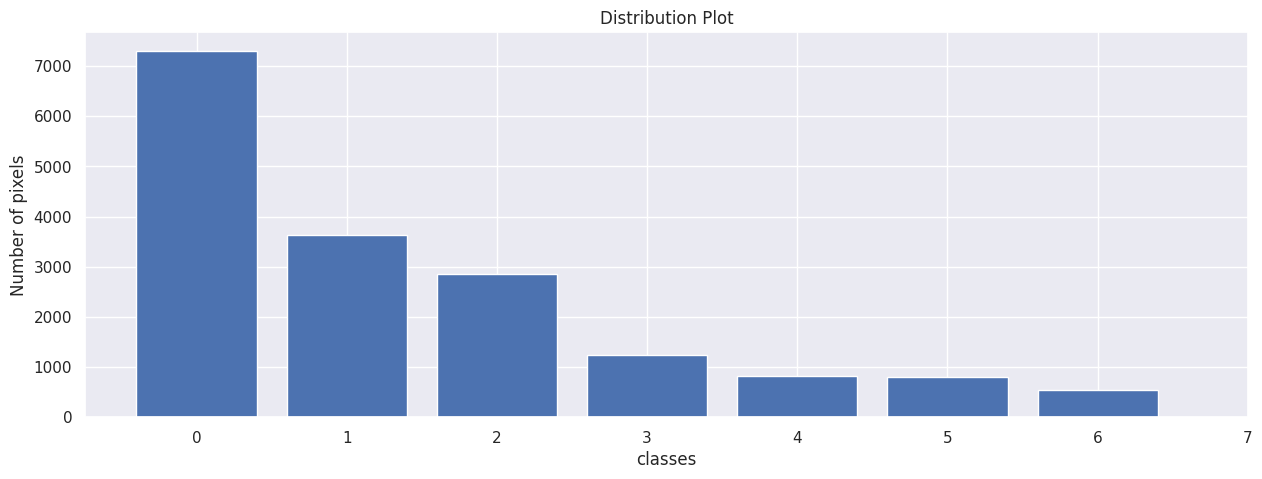

x_train: (12929, 9, 9, 6)
x_test: (4310, 9, 9, 6)
y_train: (12929,)
y_test: (4310,)


In [2]:
x = pd.read_csv(DATA_FILE).to_numpy(dtype=np.float32).reshape(H, W, B)
y = pd.read_csv(LABEL_FILE).to_numpy(dtype=np.int32).reshape(H, W)
for b in range(B):
    band = x[:, :, b]
    denom = max(float(np.max(band) - np.min(band)), 1e-8)
    x[:, :, b] = (band - np.min(band)) / denom

y_shape = y.shape[0] * y.shape[1]
pad_width = int((P_S - 1) / 2)
padded_x = np.pad(x, [(pad_width, pad_width), (pad_width, pad_width), (0, 0)], 'edge')
X, Y = [], []
for a in range(H):
    for b in range(W):
        if y[a][b] != 0:
            patch = padded_x[a:a + P_S, b:b + P_S, :]
            X.append(patch)
            Y.append(y[a][b] - 1)
X = np.array(X, dtype=np.float32)
Y = np.array(Y, dtype=np.int32)
num_classes = len(np.unique(y)) - 1
Approximate_rgb_img = x[:, :, [B // 2 - 1, B // 2, B // 2 + 1]] * 255
print('shape of x:', x.shape)
print('shape of y:', y.shape)
print('shape of padded_x:', padded_x.shape)
print(f'{len(Y) * 100 / y_shape:.4f}% of data is labeled with {num_classes} classes')
class_labels, value_counts = np.unique(y.reshape(-1, 1), return_counts=True)
plt.figure(figsize=(15, 5))
plt.bar(class_labels[1:] - 1, value_counts[1:])
plt.xticks(class_labels, rotation=0)
plt.xlabel('classes')
plt.ylabel('Number of pixels')
plt.title('Distribution Plot')
plt.show()
x_train, x_test, y_train, y_test = train_test_split(X, Y, train_size=(train_percent / 100), stratify=Y, random_state=10)
print(f'x_train: {x_train.shape}\nx_test: {x_test.shape}\ny_train: {y_train.shape}\ny_test: {y_test.shape}')





In [3]:
def plot_accuracy_loss_curve(history, use_pearson_corr = None, folder_path = None):
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']
    train_accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']

    fig = plt.figure(figsize = (24,8))
    ax = plt.subplot(1,1,1)
    ax2 = ax.twinx()
    ax.plot(train_accuracy, color='blue', marker='o', linewidth=1.5, markersize = 2,  label = 'train_accuracy')
    ax.plot(val_accuracy, color='green', marker='o', linewidth=1.5, markersize = 2, label = 'val_accuracy')
    ax.grid()
    plt.xlabel('no. of epoches')
    plt.ylabel('accuracy')
    ax.legend()
    ax2.plot(train_loss, color = 'black', marker='o', linewidth=1.5, markersize = 2, label = 'train_loss')
    ax2.plot(val_loss, color = 'red', marker='o', linewidth=1.5, markersize = 2, label = 'val_loss')
    ax2.grid()
    plt.xlabel('no. of epoches')
    plt.ylabel('loss')
    plt.title('accuracy and loss plot for model performance')
    ax2.legend()
    plt.show()
    if folder_path:
        results_dir = os.path.join(folder_path, "Results")
        os.makedirs(results_dir, exist_ok=True) # Create the directory if it doesn't exist
        if use_pearson_corr:
            path = os.path.join(results_dir, "Pearson_Corr " + str(train_percent) + "% ps_"+ str(P_S) + " accuracy_loss.png")
        else:
            path = os.path.join(results_dir, str(train_percent) + "% ps_"+ str(P_S) + " accuracy_loss.png")
        fig.savefig(path)

def performance_meausures(y_test, y_pred, tt, *parameters_summary, folder_path = None):
    Total_params, Trainable_params, Non_trainable_params = parameters_summary
    accuracy = accuracy_score(y_test, y_pred)
    kappa=cohen_kappa_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred).astype('int32')
    cr = classification_report(y_test, y_pred, output_dict=True)
    df_cr = pd.DataFrame(cr).T
    df_score = pd.DataFrame({'accuracy score: ' : [accuracy], 'Cohen_Kappa score: ' : [kappa], "Training Time: " : [tt]}).T
    df_summary = pd.DataFrame({'Total_params: ': [Total_params], 'Trainable_params: ' : [Trainable_params], 'Non_trainable_params: ':[Non_trainable_params]}).T

    spec = gridspec.GridSpec(ncols = 2, nrows = 2, width_ratios=[1,3], wspace = 0.5, hspace = 0.5, height_ratios=[7,1])

    fig = plt.figure(figsize = (24,10))

    ax1 = fig.add_subplot(spec[0])
    ax1.set_title('classification report')
    sns.heatmap(df_cr, cmap = 'Blues', cbar = False, annot = True, fmt=' .5g', ax = ax1)

    ax2 = fig.add_subplot(spec[1])
    ax2.set_title('confusion matrix')
    ax2.set_xlabel('predicted class')
    ax2.set_ylabel('actual class')
    sns.heatmap(cm, cmap = 'Blues', cbar = False, annot = True, fmt=' .5g', ax = ax2)

    ax3 = fig.add_subplot(spec[2])
    sns.heatmap(df_score, cmap = 'Blues', cbar = False, annot = True, fmt=' .5g', ax = ax3)
    ax3.set_xticks([])

    ax4 = fig.add_subplot(spec[3])
    sns.heatmap(df_summary, cmap = "Blues", cbar = False, annot = True, fmt=' .10g', ax = ax4)
    ax4.set_xticks([])

    if folder_path:
        path = folder_path + "Results/" + str(train_percent) + "% ps_" + str(P_S) +" Performance Measure.png"
        fig.savefig(path)

class Pearson_correlation_masked(layers.Layer):
    def __init__(self, P_S = 9, **kwargs):
        super(Pearson_correlation_masked, self).__init__(**kwargs)
        self.P_S = P_S

    def call(self, inputs):
        self.loc = (self.P_S)//2
        self.inputs = inputs
        self.channels = self.inputs.shape[-1]
        self.x_mean = tf.repeat(tf.math.reduce_mean(self.inputs, axis = -1, keepdims=True), repeats = self.channels, axis = -1)

        self.y = tf.repeat(tf.repeat(self.inputs[:,self.loc:self.loc+1, self.loc:self.loc+1, :], repeats = self.P_S, axis = -2), repeats = self.P_S, axis = -3)

        self.y_mean = tf.repeat(tf.math.reduce_mean(self.y, axis = -1, keepdims = True), repeats = self.channels, axis = -1)

        self.a = tf.math.subtract(self.inputs, self.x_mean)
        self.b = tf.math.subtract(self.y, self.y_mean)
        self.ab = tf.math.multiply(self.a,self.b)
        self.num = tf.math.reduce_sum(self.ab, axis = -1, keepdims = True)

        self.a_new = tf.math.reduce_sum(tf.math.multiply(self.a, self.a), axis = -1, keepdims = True)
        self.b_new = tf.math.reduce_sum(tf.math.multiply(self.b, self.b), axis = -1, keepdims = True)
        self.deno = tf.math.sqrt(tf.math.multiply(self.a_new, self.b_new))

        self.corr = tf.math.divide(self.num, self.deno)

        self.thresh = tf.math.reduce_mean(self.corr)
        self.mask = self.corr > self.thresh
        self.mask = tf.cast(self.mask, self.corr.dtype)

        self.masked_corr = tf.math.multiply(self.mask, self.corr)

        self.attention_weights = tf.repeat(self.masked_corr, repeats = self.channels, axis = -1)
        return multiply([self.inputs, self.attention_weights])

    def get_config(self, **kwargs):
        config = super(Pearson_correlation_masked, self).get_config()
        config.update({
            "P_S": self.P_S,
        })
        return config

@keras_export('keras.layers.Dropout')
class Dropout_Train(layers.Layer):
    def __init__(self, rate, shift = 1, noise_shape=None, seed=None, **kwargs):
        super(Dropout_Train, self).__init__(**kwargs)

        if isinstance(rate, (int, float)) and not 0 <= rate <= 1:
            raise ValueError(f"Invalid value {rate} received for `rate`, expected a value between 0 and 1.")
        if type(shift) != int:
            raise TypeError(f"Invalid dtype {type(shift)} found for `shift`. It must be an integer")
        if shift*rate > 1.0:
            raise ValueError(f"Invalid value {shift} received for `shift`, expected an integer value less than or equal to {int(1/rate)}")
        self.rate = rate
        self.shift = shift
        self.noise_shape = noise_shape
        self.seed = seed
        self.supports_masking = True

    def _get_noise_shape(self, inputs):
        if self.noise_shape is None:
            return None

        concrete_inputs_shape = array_ops.shape(inputs)
        noise_shape = []
        for i, value in enumerate(self.noise_shape):
            noise_shape.append(concrete_inputs_shape[i] if value is None else value)
        return tf.convert_to_tensor(noise_shape)

    def call(self, inputs, training=None):
        if self.rate == 0:
            return tf.identity(inputs)

        if training is None:
            training = K.learning_phase()

        def dropped_inputs():
            input_shape = inputs.shape
            range_0 = int(self.rate*(self.shift-1)*input_shape[-1])
            if self.shift*self.rate < 1.0:
                range_1 = int(self.rate*(self.shift)*input_shape[-1])
            else:
                range_1 = None
            input_shape = inputs.shape
            multiplier = np.ones(input_shape[-1])
            multiplier[range_0:range_1] = 0.0
            multiplier = tf.constant(multiplier)
            return Multiply()([inputs, multiplier])

        output = control_flow_util.smart_cond(training, dropped_inputs, lambda: array_ops.identity(inputs))
        return output

    def compute_output_shape(self, input_shape):
        return input_shape

    def get_config(self):
        config = super(Dropout_Train, self).get_config()
        config.update({
            "rate": self.rate,
            "shift": self.shift,
            "noise_shape": self.noise_shape,
            "seed": self.seed,
            "supports_masking": self.supports_masking
        })
        return config

def modified_model(model, layer_name, rate, new_layer, shift, **kwargs):    # layer_name = "TRAIN_DROPOUT"
    name = kwargs["name"] if kwargs else None
    x = model.layers[0].output
    modification = False
    z = 0
    for lyr in model.layers[1:]:
        if (layer_name in lyr.name or layer_name in lyr.name.upper()) and (type(shift) != str):
            x = new_layer(rate = rate, shift = shift, name = layer_name + "_" + str(shift) + "_" + str(z))(x)
            modification = True
            z += 1
        elif (layer_name in lyr.name or layer_name in lyr.name.upper()) and (type(shift) == str):
            x = new_layer(rate = rate, name = layer_name + "_" + str(shift) + "_" + str(z))(x)
            z += 1
            modification = True
        else:
            x = lyr(x)
    if not modification:
        print("___________________________________Model has not been modified___________________________________")
    return Model(inputs = model.layers[0].input, outputs = x, name = name)

class Custom_callbacks(tf.keras.callbacks.Callback):
    def __init__(self, filepath, epochs, rate, new_layer = Dropout_Train, layer_name = "DROPOUT", accuracy_score = 0.99, min_epochs = 50):
        super(Custom_callbacks, self).__init__()
        self.filepath = filepath
        self.epochs = epochs
        self.new_layer = new_layer
        self.rate = rate
        self.best = 0.0
        self.epoch_num = 1
        self.layer_name = layer_name
        self.min_epochs = min_epochs                    # minimum number of epochs that model should be trained in each shift
        self.accuracy_score = accuracy_score if accuracy_score <= 1.0 else accuracy_score/100.0

    def on_train_begin(self, logs=None):
        print(self.epochs)
        keys = list(logs.keys())
        self.shift = 1
        self.epoch_completed = 0
        print(f"Model will be trained in {int(1/self.rate)} shifts")
        print("Starting training with 1st shift \n")
        self.model = modified_model(self.model, self.layer_name, self.rate, self.new_layer, self.shift)

    def on_train_end(self, logs=None):
        keys = list(logs.keys())
        if self.shift <= int(1/self.rate):
            raise NotImplementedError(f"model has not trained fully in the available no. of epochs \n only {self.shift-1} shifts completed out of {int(1/self.rate)}")
        print("Model training completition ", "███████████"*self.shift, (self.rate*(self.shift-1))*100, "%")
        print(f"Model has been fully trained in {int(1/self.rate)} shifts")
        self.model.set_weights(self.best_weights)
        print(f"\nSaving best model to {self.filepath}")
        self.model.save(self.filepath)

    def on_epoch_end(self, epoch, logs=None):
        keys = list(logs.keys())
        self.epoch_completed += 1
        self.epoch_num += 1

        if (logs["val_accuracy"] >= self.accuracy_score) and (self.epoch_completed >= self.min_epochs) and (self.shift < int(1/self.rate)):
            print("\nTargeted accuracy has been achieved")
            print("Model training completition ", "███████████"*(self.shift), (self.rate*self.shift)*100, "%")
            self.shift += 1
            Suffixes = "nd" if (self.shift == 2) else "th"
            print(f"Modifying the model for {self.shift}{str(Suffixes)} shift")
            self.model = modified_model(self.model, self.layer_name, self.rate, self.new_layer, self.shift)
            self.epoch_completed = 0

        elif (logs["val_accuracy"] >= self.accuracy_score) and (self.epoch_completed >= self.min_epochs) and (self.shift == int(1/self.rate)):
            print("\nModel training completition ", "███████████"*(self.shift), (self.rate*self.shift)*100, "%")
            print("All shifting has been completed\n")
            print("██████████████████████===============> Now redefining the model to standard model <===============██████████████████████")
            self.model = modified_model(self.model, self.layer_name, self.rate, self.new_layer, "Final", name = "AlexNet")
            self.shift += 1
            self.epoch_completed = 0

        else:
            print(", need more training")
            if self.shift >= int(1/self.rate):
                current = logs.get("val_accuracy")
                if not np.less(current, self.best) and (self.epoch_num >= self.epochs-10):
                    print(f"val_accuracy improved from {self.best:.4f} to {current:.4f}")
                    self.best = current
                    self.best_weights = self.model.get_weights()

    def get_config(self):
        config = super(Custom_callbacks, self).get_config()
        config.update({
            "filepath": self.filepath,
            "epochs": self.epochs,
            "new_layer": self.new_layer,
            "rate": self.rate,
            "best": self.best,
            "epoch_num": self.epoch_num,
            "layer_name": self.layer_name,
            "min_epochs": self.min_epochs,
            "accuracy_score": self.accuracy_score,
        })
        return config




In [4]:
def AlexNet(input_shape, num_classes=13, use_pearson_corr=False, dropout_rate=0.5):
    K_HEADS = 7  # Number of separate output heads

    x_input = Input(input_shape)
    if use_pearson_corr:
        X = Pearson_correlation_masked(P_S)(x_input)
    else:
        X = x_input

    # Convolutional backbone
    X = Conv2D(filters=96, kernel_size=(3,3), activation='relu', strides=(1,1), padding='same')(X)
    X = Conv2D(filters=256, kernel_size=(3,3), activation='relu', strides=(1,1), padding='same')(X)
    X = Conv2D(filters=384, kernel_size=(3,3), activation='relu', strides=(1,1), padding='same')(X)
    X = Conv2D(filters=384, kernel_size=(3,3), activation='relu', strides=(1,1), padding='same')(X)
    X = Conv2D(filters=256, kernel_size=(3,3), activation='relu', strides=(1,1), padding='same')(X)
    X = MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='same')(X)

    # Flatten and dense layers
    X = Flatten()(X)
    X = Dense(4096, activation='relu')(X)
    X = Dropout(dropout_rate, name="TRAIN_DROPOUT_1")(X)
    X = Dense(1024, activation='relu')(X)
    X = Dropout(dropout_rate, name="TRAIN_DROPOUT_2")(X)
    X = Dense(256, activation='relu')(X)
    X = Dropout(dropout_rate, name="TRAIN_DROPOUT_3")(X)
    X = Dense(32, activation='relu')(X)

    # --- START OF MULTI-HEAD MODIFICATION ---
    output_heads = []
    for i in range(K_HEADS):
        head_name = f'head_{i+1}'
        head_output = Dense(num_classes, activation='softmax', dtype='float32', name=head_name)(X)
        output_heads.append(head_output)

    model = Model(inputs=x_input, outputs=output_heads, name="MultiHead_AlexNet")
    # --- END OF MULTI-HEAD MODIFICATION ---

    return model





In [5]:
class GF_MLP(layers.Layer):
    def __init__(self, in_features, out_features, drop = 0.0, **kwargs):
        super(GF_MLP, self).__init__(**kwargs)
        self.in_features = in_features
        self.out_features = out_features
        self.drop = drop
        self.mlp_1 = Dense(in_features, activation = activations.gelu, use_bias = False)
        self.drop_1 = Dropout(drop)
        self.mlp_2 = Dense(out_features, activation = activations.gelu, use_bias = False)
        self.drop_2 = Dropout(drop)

    def call(self, x):
        x = self.drop_1(self.mlp_1(x))
        x = self.drop_2(self.mlp_2(x))
        return x

    def get_config(self, **kwargs):
        config = super(GF_MLP, self).get_config()
        config.update({
            "in_features": self.in_features,
            "out_features": self.out_features,
            "drop": self.drop,
        })
        return config

class GF_DropPath(layers.Layer):
    def __init__(self, drop_prob = 0.0, training = False, **kwargs):
        super(GF_DropPath, self).__init__(**kwargs)
        self.drop_prob = drop_prob
        self.training = training
    def call(self, x, **kwargs):
        if self.drop_prob == 0. or not self.training:
            return x
        keep_prob = 1 -  self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = keep_prob + tf.random.uniform(shape, dtype=x.dtype)
        random_tensor.floor_()  # binarize
        output = tf.divide(x, keep_prob) * random_tensor
        return output
    def get_config(self, **kwargs):
        config = super(GF_DropPath, self).get_config()
        config.update({
            "drop_prob": self.drop_prob,
            "training": self.training,
        })
        return config

class GF_Expand_Dims(layers.Layer):
    def __init__(self, ndim, **kwargs):
        super(GF_Expand_Dims, self).__init__(**kwargs)
        self.ndim = ndim

    def call(self, x):
        x = tf.expand_dims(x, axis = self.ndim)
        return x

    def config(self, **kwargs):
        config = super(GF_Expand_Dims, self).config()
        config.update({
            "ndim" : self.ndim,
        })
        return config

class GF_Patches(layers.Layer):
    def __init__(self, patch_size = 3, hidden_dim = 256, patch_method='extract', **kwargs):
        super(GF_Patches, self).__init__(**kwargs)
        self.patch_size = patch_size
        self.hidden_dim = hidden_dim
        self.patch_method = patch_method.lower()

    def call(self, images):
        if self.patch_method == "conv":
            x = Conv2D(self.hidden_dim, self.patch_size, self.patch_size)(images)              # shape(B, 3, 3, 256)
            patches = Reshape([-1, x.shape[-1]])(x)                                   # shape(B, 9, 256)
            return patches
        else:
            batch_size = tf.shape(images)[0]
            patches = tf.image.extract_patches(images=images, sizes=[1, self.patch_size, self.patch_size, 1], strides=[1, self.patch_size, self.patch_size, 1],
                                            rates=[1, 1, 1, 1], padding="VALID",)
            patch_dims = patches.shape[-1]
            patches = tf.reshape(patches, [batch_size, -1, patch_dims])
            return patches
    def get_config(self):
        config = super(GF_Patches, self).get_config()
        config.update({
            "patch_size": self.patch_size,
            "hidden_dim": self.hidden_dim,
            "patch_method": self.patch_method
        })
        return config

class GF_PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super(GF_PatchEncoder, self).__init__(**kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)

    def call(self, patch,**kwargs):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded

    def get_config(self, **kwargs):
        config = super(GF_PatchEncoder, self).get_config()
        config.update({
            "num_patches": self.num_patches,
            "projection_dim": self.projection_dim,
        })
        return config

class GF_GlobalFilter(layers.Layer):
    def __init__(self, patch_size, dim, **kwargs):
        super(GF_GlobalFilter, self).__init__(**kwargs)
        self.patch_size = patch_size
        self.dim = dim

    def build(self, input_shape):
        w_init = tf.random_uniform_initializer()
        self.complex_weight = self.add_weight(
            name="complex_weight",
            shape=(self.patch_size, self.patch_size, input_shape[-1] // 2 + 1, 2),
            initializer=w_init,
            trainable=True
        )
        super().build(input_shape)

    def call(self, x, **kwargs):
        B, N, C = x.shape
        a = b = int(math.sqrt(N))
        x = tf.reshape(x, [-1, a, b, C])
        x = tf.signal.rfft2d(x)
        weight = tf.dtypes.complex(self.complex_weight[:,:,:,0], self.complex_weight[:,:,:,-1])
        x = x * weight
        x = tf.signal.irfft2d(x)
        x = tf.reshape(x, [-1, N, C])
        return x

    def config(self, **kwargs):
        config = super(GF_GlobalFilter, self).config()
        config.update({
            "patch_size" : self.patch_size,
            "dim" : self.patch_size,
        })
        return config

class GF_Block(tf.keras.layers.Layer):
    def __init__(self, patch_size=3, dim=512, mlp_ratio=4.0, drop=0.0, drop_path=0.0, **kwargs):
        super(GF_Block, self).__init__(**kwargs)
        self.patch_size = patch_size
        self.dim = dim
        self.mlp_ratio = mlp_ratio
        self.drop = drop
        self.drop_path_rate = drop_path

        # Define sublayers
        self.norm1 = tf.keras.layers.LayerNormalization(axis=-1)
        self.filter = GF_GlobalFilter(patch_size, dim)  # Make sure GlobalFilter uses add_weight inside its build()
        self.drop_path = GF_DropPath(drop_path)
        self.norm2 = tf.keras.layers.LayerNormalization(axis=-1)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = GF_MLP(in_features=mlp_hidden_dim, out_features=dim, drop=drop)

    def call(self, x):
        # Transformer-like residual block
        x = x + self.drop_path(self.mlp(self.norm2(self.filter(self.norm1(x)))))
        return x

    def get_config(self):
        config = super(GF_Block, self).get_config()
        config.update({
            "patch_size": self.patch_size,
            "dim": self.dim,
            "mlp_ratio": self.mlp_ratio,
            "drop": self.drop,
            "drop_path": self.drop_path_rate,
        })
        return config

def GFNet(input_shape=(P_S, P_S, B),
          use_pearson_corr=False,
          patch_size=3,
          num_classes=16,
          hidden_dim=512,
          GlobalFilter_layers=12,
          mlp_ratio=4,
          num_patches=9,
          dropout_rate=0.0,
          drop_path_rate=0.0):

    K_HEADS = 7  # Number of separate output heads

    # --- Input & optionally apply Pearson correlation ---
    x_input = Input(shape=input_shape)
    if use_pearson_corr:
        x = Pearson_correlation_masked(P_S)(x_input)
    else:
        x = x_input

    # --- Patch extraction and encoding ---
    x = GF_Patches(patch_size)(x)                     # shape e.g. (num_patches, patch_dim)
    x = GF_PatchEncoder(num_patches, hidden_dim)(x)   # encodes patches
    x = Dropout(dropout_rate, name="TRAIN_DROPOUT_1")(x)

    # --- Global Filter layers ---
    for _ in range(GlobalFilter_layers):
        x = GF_Block(
            patch_size=patch_size,
            dim=hidden_dim,
            mlp_ratio=mlp_ratio,
            drop=dropout_rate,
            drop_path=drop_path_rate
        )(x)

    # --- Pooling and normalization ---
    x = Dropout(dropout_rate, name="TRAIN_DROPOUT_2")(x)
    x = LayerNormalization()(x)
    x = GF_Expand_Dims(ndim=2)(x)
    x = GlobalAveragePooling2D()(x)
    x = Flatten()(x)
    x = Dropout(dropout_rate, name="TRAIN_DROPOUT_3")(x)

    # --- START OF MULTI-HEAD MODIFICATION ---
    output_heads = []
    for i in range(K_HEADS):
        head_name = f"head_{i+1}"
        head_output = Dense(num_classes, activation="softmax", dtype="float32", name=head_name)(x)
        output_heads.append(head_output)

    model = keras.Model(inputs=x_input, outputs=output_heads, name="MultiHead_GFNet")
    # --- END OF MULTI-HEAD MODIFICATION ---

    return model




In [6]:
class ViT_SpatialAttention(layers.Layer):
    def __init__(self, k_size=3, **kwargs):
        super().__init__(**kwargs)
        self.k_size = k_size
        self.norm = layers.BatchNormalization()
        self.conv1 = layers.Conv2D(1, kernel_size=(k_size, k_size), padding="same")
        self.conv2 = layers.Conv2D(1, kernel_size=(k_size, k_size), padding="same")
        self.conv3 = layers.Conv2D(1, kernel_size=(k_size, k_size), padding="same")
        self.conv4 = layers.Conv2D(1, kernel_size=(k_size, k_size), padding="same")
        self.act_relu = layers.Activation("relu")
        self.act_sigmoid = layers.Activation("sigmoid")

    def call(self, inputs):
        x = self.conv1(inputs)
        x = self.norm(x)
        x = self.conv2(x)
        x = self.act_relu(x)
        x = self.conv3(x)
        x = self.act_relu(x)
        x = self.conv4(x)
        return self.act_sigmoid(x)

    def get_config(self):
        config = super().get_config()
        config.update({"k_size": self.k_size})
        return config

class ViT_SpatialAttention1(layers.Layer):
    def __init__(self, input_shape, **kwargs):
        super().__init__(**kwargs)
        self.input_shape_val = input_shape
        self.filters = input_shape[-1]
        self.k_size = input_shape[1]

        self.norm = layers.BatchNormalization()
        self.conv1 = layers.Conv2D(self.filters, kernel_size=3, padding="same", kernel_initializer="he_normal")
        self.conv2 = layers.Conv2D(self.filters, kernel_size=3, strides=2, padding="same")
        self.conv3 = layers.Conv2D(self.filters, kernel_size=3, strides=2, padding="same")

        self.convt1 = layers.Conv2DTranspose(self.filters, kernel_size=3, strides=2, padding="same")
        self.convt2 = layers.Conv2DTranspose(self.filters, kernel_size=3, strides=2, padding="same")

        self.relu = layers.ReLU()
        self.sigmoid = layers.Activation("sigmoid")

    def call(self, inputs):
        x = self.conv1(inputs)
        x = self.norm(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.relu(x)

        x = self.conv3(x)
        x = self.relu(x)

        x = self.convt1(x)
        x = self.relu(x)

        x = self.convt2(x)
        x = self.relu(x)

        # shape correction if needed
        if x.shape[1] != self.input_shape_val[1] or x.shape[2] != self.input_shape_val[2]:
            k_size = x.shape[1] - self.k_size + 1
            x = layers.Conv2D(self.filters, kernel_size=k_size, strides=1, padding="valid")(x)

        return self.sigmoid(x)

    def get_config(self):
        config = super().get_config()
        config.update({
            "input_shape": self.input_shape_val,
            "filters": self.filters,
            "k_size": self.k_size
        })
        return config

# Implement Feed Forward Network / MLP
def MLP(x, hidden_units, dropout_rate):
    """
    Feedforward network used inside Transformer blocks.
    hidden_units: list of layer sizes (e.g. [mlp_dim, embed_dim])
    dropout_rate: dropout between dense layers
    """
    for units in hidden_units:
        # Use GELU activation, which is common in ViTs
        x = layers.Dense(units, activation=tf.keras.activations.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x


# Implement patch creation as a layer
class ViT_Patches(layers.Layer):
    def __init__(self, patch_size, embed_dim=768, **kwargs):
        super(ViT_Patches, self).__init__(**kwargs)
        self.patch_size = patch_size
        self.embed_dim = embed_dim

    def build(self, input_shape):
        # Flatten each patch across spatial + spectral channels, then project
        _, H, W, C = input_shape
        patch_dim = self.patch_size * self.patch_size * C
        self.projection = layers.Dense(self.embed_dim)

    def call(self, images):
        batch_size = tf.shape(images)[0]

        # Extract non-overlapping patches
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]   # = patch_size*patch_size*C
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])

        # Project raw patches to embedding dimension for the transformer
        return self.projection(patches)

    def get_config(self):
        config = super(ViT_Patches, self).get_config()
        config.update({
            "patch_size": self.patch_size,
            "embed_dim": self.embed_dim,
        })
        return config

class ViT_PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super(ViT_PatchEncoder, self).__init__(**kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim

        # Linear projection of patches → projection_dim
        self.projection = layers.Dense(units=projection_dim)

        # Position embedding (num_patches + 1 to include CLS token)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches + 1, output_dim=projection_dim
        )

        # Learnable class token
        cls_init = tf.zeros_initializer()
        self.cls_token = self.add_weight(
            name="cls_token",
            shape=(1, 1, projection_dim),
            initializer=cls_init,
            trainable=True,
        )

    def call(self, patch, **kwargs):
        batch_size = tf.shape(patch)[0]

        # Project patches [B, num_patches, projection_dim]
        patch_proj = self.projection(patch)

        # Broadcast cls token for this batch [B, 1, projection_dim]
        cls_tokens = tf.repeat(self.cls_token, repeats=batch_size, axis=0)

        # Concatenate CLS + patch sequence
        x = tf.concat([cls_tokens, patch_proj], axis=1)

        # Add position embeddings
        positions = tf.range(start=0, limit=self.num_patches + 1, delta=1)
        pos_embeddings = self.position_embedding(positions)
        encoded = x + pos_embeddings

        return encoded

    def get_config(self):
        config = super(ViT_PatchEncoder, self).get_config()
        config.update({
            "num_patches": self.num_patches,
            "projection_dim": self.projection_dim,
        })
        return config

class ViT_Weighted_add(layers.Layer):
    def __init__(self, name, **kwargs):
        super(ViT_Weighted_add, self).__init__(**kwargs)
        self.wt_name = name

    def build(self, input_shape):
        # Use add_weight instead of raw tf.Variable
        self.w = self.add_weight(
            name="weighted_add_" + str(self.wt_name),
            shape=(1,),
            initializer=tf.random_normal_initializer(),
            trainable=True
        )

    def call(self, input_1, input_2):
        return input_1 * self.w + input_2 * (1.0 - self.w)

    def get_config(self):
        config = super(ViT_Weighted_add, self).get_config()
        config.update({
            "wt_name": self.wt_name,
        })
        return config

class ViT_TransFormer(layers.Layer):
    def __init__(self, layer_num, num_heads, projection_dim, dropout=0.1, **kwargs):
        super(ViT_TransFormer, self).__init__(**kwargs)
        self.layer_num = layer_num
        self.num_heads = num_heads
        self.projection_dim = projection_dim
        self.dropout = dropout

    def build(self, input_shape):
        self.norm1 = layers.LayerNormalization(epsilon=1e-6, name=f"ln1_{self.layer_num}")
        self.norm2 = layers.LayerNormalization(epsilon=1e-6, name=f"ln2_{self.layer_num}")

        self.add1 = ViT_Weighted_add(f"transformer_1_{self.layer_num}")
        self.add2 = ViT_Weighted_add(f"transformer_2_{self.layer_num}")

        self.mha = layers.MultiHeadAttention(
            num_heads=self.num_heads,
            key_dim=self.projection_dim,
            dropout=self.dropout,
            name=f"mha_{self.layer_num}"
        )

        self.dense1 = layers.Dense(self.projection_dim * 2, activation=tf.keras.activations.gelu)
        self.drop1 = layers.Dropout(self.dropout)

        self.dense2 = layers.Dense(self.projection_dim, activation=tf.keras.activations.gelu)
        self.drop2 = layers.Dropout(self.dropout)

    def call(self, inputs, training=None):
        # Multi-Head Attention block
        x1 = self.norm1(inputs)
        x1 = self.mha(x1, x1, training=training)
        x1 = self.add1(x1, inputs)   # residual with learned weighting

        # Feed Forward block
        x2 = self.norm2(x1)
        x2 = self.dense1(x2)
        x2 = self.drop1(x2, training=training)
        x2 = self.dense2(x2)
        x2 = self.drop2(x2, training=training)

        return self.add2(x2, x1)     # residual with learned weighting

    def get_config(self):
        config = super(ViT_TransFormer, self).get_config()
        config.update({
            "layer_num": self.layer_num,
            "num_heads": self.num_heads,
            "projection_dim": self.projection_dim,
            "dropout": self.dropout
        })
        return config

class ViT_TransFormer_Block(layers.Layer):
    def __init__(self, num_layers, num_heads, projection_dim, dropout=0.1, **kwargs):
        super(ViT_TransFormer_Block, self).__init__(**kwargs)
        self.num_layers = num_layers
        self.num_heads = num_heads
        self.projection_dim = projection_dim
        self.dropout = dropout

    def build(self, input_shape):
        # Build list of TransFormer layers
        self.Blocks = [
            ViT_TransFormer(i, self.num_heads, self.projection_dim, self.dropout)
            for i in range(self.num_layers)
        ]

    def call(self, inputs, training=None):
        block_list = []
        x = inputs
        for i in range(self.num_layers):
            if i <= self.num_layers // 2:
                x = self.Blocks[i](x, training=training)
                block_list.append(x)
            else:
                x = self.Blocks[i](x, training=training)
                # Symmetric skip connection (mirror like U‑Net)
                x = layers.Add()([x, block_list[self.num_layers - i - 1]])
        return x

    def get_config(self):
        config = super(ViT_TransFormer_Block, self).get_config()
        config.update({
            "num_layers": self.num_layers,
            "num_heads": self.num_heads,
            "projection_dim": self.projection_dim,
            "dropout": self.dropout,
        })
        return config

class ViT_Class_Token_Norm(layers.Layer):
    def __init__(self, eps=1e-6, **kwargs):
        super(ViT_Class_Token_Norm, self).__init__(**kwargs)
        self.eps = eps
        self.norm = layers.LayerNormalization(epsilon=self.eps)

    def call(self, inputs):
        # Normalize entire sequence, then extract CLS token
        x = self.norm(inputs)
        cls_token = x[:, 0, :]     # shape (B, D)
        return cls_token

    def get_config(self):
        config = super(ViT_Class_Token_Norm, self).get_config()
        config.update({
            "eps": self.eps
        })
        return config

projection_dim = 256
num_heads = 4
transformer_layers = 12
dropout = 0.1          # dropout inside Transformer blocks

def create_vit_classifier(input_shape=(P_S, P_S, B),
                          num_classes=7,
                          use_pearson_corr=False,
                          dropout_rate=0.25,
                          method="with_gap",
                          k_heads: int = 1):
    """
    Vision Transformer classifier with optional multi-head outputs.
    - k_heads: number of classification heads (each head = independent Dense softmax).
      If k_heads == 1 -> returns a single logits tensor (shape [B, num_classes]).
      If k_heads > 1 -> returns a list of k_heads tensors [ (B,num_classes), ... ].
    """
    inputs = layers.Input(shape=input_shape)

    # Optional Pearson correlation preprocessing
    if use_pearson_corr:
        x0 = Pearson_correlation_masked(P_S)(inputs)
    else:
        x0 = inputs

    # Patch creation
    patches = ViT_Patches(patch_size, embed_dim=projection_dim)(x0)

    # Patch encoding
    encoded_patches = ViT_PatchEncoder(num_patches, projection_dim)(patches)

    # Transformer stack
    encoded_patches = ViT_TransFormer_Block(transformer_layers, num_heads, projection_dim, dropout)(encoded_patches)
    encoded_patches = layers.Dropout(dropout_rate, name="TRAIN_DROPOUT_1")(encoded_patches)

    # Representation strategies
    if method == "with_cls_tkn":
        # normalize + extract CLS token
        representation = ViT_Class_Token_Norm(eps=1e-6)(encoded_patches)
    elif method == "without_gap":
        representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        representation = layers.Flatten()(representation)
    elif method == "with_gap":
        representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        representation = tf.reduce_mean(representation, axis=1)  # [B, D]
    else:
        raise ValueError(f"Unknown method: {method}")

    # Classification head (shared backbone -> separate heads)
    x = layers.Dense(512, activation=tf.keras.activations.gelu)(representation)
    x = layers.Dropout(dropout_rate, name="TRAIN_DROPOUT_3")(x)
    x = layers.Dense(256, activation=tf.keras.activations.gelu)(x)
    x = layers.Dense(128, activation=tf.keras.activations.gelu)(x)
    x = layers.Dropout(dropout_rate, name="TRAIN_DROPOUT_5")(x)
    x = layers.Dense(64, activation=tf.keras.activations.gelu)(x)
    features = layers.Dropout(dropout_rate, name="TRAIN_DROPOUT_6")(x)

    # Build k_heads softmax outputs
    output_heads = []
    for i in range(max(1, k_heads)):
        head_name = f"head_{i+1}"
        head_logits = layers.Dense(num_classes, activation="softmax", dtype="float32", name=head_name)(features)
        output_heads.append(head_logits)

    # Return single tensor if only 1 head (backwards compatibility)
    if k_heads == 1:
        model = keras.Model(inputs=inputs, outputs=output_heads[0])
    else:
        model = keras.Model(inputs=inputs, outputs=output_heads)

    return model





In [7]:
patch_size = 3
hidden_dim = 512
GlobalFilter_layers = 12
mlp_ratio = 4
num_patches = 9
projection_dim = 256
num_heads = 4
transformer_layers = 12
dropout = 0.1

CUSTOM_OBJECTS = {
    'Pearson_correlation_masked': Pearson_correlation_masked,
    'Dropout_Train': Dropout_Train,
    'GF_Patches': GF_Patches,
    'GF_PatchEncoder': GF_PatchEncoder,
    'GF_GlobalFilter': GF_GlobalFilter,
    'GF_Block': GF_Block,
    'GF_Expand_Dims': GF_Expand_Dims,
    'GF_MLP': GF_MLP,
    'GF_DropPath': GF_DropPath,
    'ViT_Patches': ViT_Patches,
    'ViT_PatchEncoder': ViT_PatchEncoder,
    'ViT_SpatialAttention': ViT_SpatialAttention,
    'ViT_SpatialAttention1': ViT_SpatialAttention1,
    'ViT_Weighted_add': ViT_Weighted_add,
    'ViT_TransFormer': ViT_TransFormer,
    'ViT_TransFormer_Block': ViT_TransFormer_Block,
    'ViT_Class_Token_Norm': ViT_Class_Token_Norm,
}

MODEL_SPECS = {
    'AlexNet_CNN_MultiHead': {
        'builder': lambda: AlexNet(input_shape=(P_S, P_S, B), num_classes=num_classes, use_pearson_corr=use_pearson_corr, dropout_rate=dropout_rate),
        'optimizer': lambda: optimizers.Adagrad(0.01),
        'lr_schedule': 'alexnet',
        'model_file': SAVED_MODEL_DIR / 'AlexNet_CNN_MultiHead_best.keras',
        'final_file': SAVED_MODEL_DIR / 'AlexNet_CNN_MultiHead_final.keras',
    },
    'GFNet_MultiHead': {
        'builder': lambda: GFNet((P_S, P_S, B), use_pearson_corr, patch_size, num_classes, hidden_dim, GlobalFilter_layers, mlp_ratio, num_patches, dropout_rate, 0.0),
        'optimizer': lambda: tf.keras.optimizers.Adam(learning_rate=0.000003),
        'lr_schedule': 'gfnet',
        'model_file': SAVED_MODEL_DIR / 'GFNet_MultiHead_best.keras',
        'final_file': SAVED_MODEL_DIR / 'GFNet_MultiHead_final.keras',
    },
    'ViT_UNet_MultiHead': {
        'builder': lambda: create_vit_classifier(input_shape=(P_S, P_S, B), num_classes=num_classes, use_pearson_corr=use_pearson_corr, dropout_rate=dropout_rate, method='with_cls_tkn', k_heads=7),
        'optimizer': lambda: optimizers.Adam(3e-6),
        'lr_schedule': 'vit',
        'model_file': SAVED_MODEL_DIR / 'ViT_UNet_MultiHead_best.keras',
        'final_file': SAVED_MODEL_DIR / 'ViT_UNet_MultiHead_final.keras',
    },
}

def ensure_workbook(path):
    if path.exists():
        return load_workbook(path)
    wb = Workbook()
    ws = wb.active
    ws.title = 'Summary'
    wb.save(path)
    return wb

def autosize_columns(ws):
    for col in ws.columns:
        values = [len(str(cell.value)) for cell in col if cell.value is not None]
        if values:
            ws.column_dimensions[col[0].column_letter].width = min(max(values) + 2, 40)

def fig_to_buffer(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=200)
    buf.seek(0)
    return buf

def build_lr_callback(kind):
    if kind == 'alexnet':
        LR_START, LR_MAX, LR_MIN = 0.01, 0.02, 0.005
        STEPS = [epoch, epoch * 2, epoch * 3]
        def lrfn(e):
            if e < STEPS[0]:
                epoch2, EPOCHS2 = e, STEPS[0]
            elif e < STEPS[0] + STEPS[1]:
                epoch2, EPOCHS2 = e - STEPS[0], STEPS[1]
            else:
                epoch2, EPOCHS2 = e - STEPS[0] - STEPS[1], STEPS[2]
            decay_total_epochs = EPOCHS2 - 1
            phase = math.pi * epoch2 / decay_total_epochs
            cosine_decay = 0.5 * (1 + math.cos(phase))
            return (LR_MAX - LR_MIN) * cosine_decay + LR_MIN
    elif kind == 'gfnet':
        LR_START, LR_MAX, LR_MIN = 3e-4, 6e-4, 1e-7
        STEPS = [epoch, epoch * 2, epoch * 3]
        def lrfn(e):
            if e < STEPS[0]:
                epoch2, EPOCHS2 = e, STEPS[0]
            elif e < STEPS[0] + STEPS[1]:
                epoch2, EPOCHS2 = e - STEPS[0], STEPS[1]
            else:
                epoch2, EPOCHS2 = e - STEPS[0] - STEPS[1], STEPS[2]
            decay_total_epochs = EPOCHS2 - 1
            phase = math.pi * epoch2 / decay_total_epochs
            cosine_decay = 0.5 * (1 + math.cos(phase))
            return (LR_MAX - LR_MIN) * cosine_decay + LR_MIN
    else:
        LR_START, LR_MAX, LR_MIN = 3e-4, 6e-4, 1e-7
        def lrfn(e):
            decay_total_epochs = epoch - 1
            phase = math.pi * e / decay_total_epochs
            cosine_decay = 0.5 * (1 + math.cos(phase))
            return (LR_MAX - LR_MIN) * cosine_decay + LR_MIN
    rng = [i for i in range(epoch)]
    lr_y = [lrfn(x) for x in rng]
    fig = plt.figure(figsize=(10, 4))
    plt.plot(rng, lr_y, '-o')
    plt.xlabel('Epoch', size=14)
    plt.ylabel('Learning Rate', size=14)
    plt.title(f'Learning rate schedule: {kind}')
    plt.show()
    return tf.keras.callbacks.LearningRateScheduler(lrfn, verbose=True), fig

def predict_multihead(model, x_data):
    y_pred_list = model.predict(x_data, verbose=0)
    y_pred_stacked = np.stack(y_pred_list, axis=0)
    y_pred_avg_probs = np.mean(y_pred_stacked, axis=0)
    y_pred_argmax = np.argmax(y_pred_avg_probs, axis=1)
    return y_pred_argmax.reshape(-1, 1), y_pred_avg_probs

def parameter_summary(model):
    trainable = int(np.sum([np.prod(v.shape) for v in model.trainable_weights]))
    non_trainable = int(np.sum([np.prod(v.shape) for v in model.non_trainable_weights]))
    return int(trainable + non_trainable), trainable, non_trainable

def history_figure(history, model_name):
    fig = plt.figure(figsize=(24, 8))
    ax = plt.subplot(1, 1, 1)
    ax2 = ax.twinx()
    ax.plot(history.history.get('head_1_accuracy', []), color='blue', marker='o', linewidth=1.5, markersize=2, label='train_head_1_accuracy')
    ax.plot(history.history.get('val_head_1_accuracy', []), color='green', marker='o', linewidth=1.5, markersize=2, label='val_head_1_accuracy')
    ax.grid()
    ax.legend()
    ax2.plot(history.history.get('loss', []), color='black', marker='o', linewidth=1.5, markersize=2, label='train_loss')
    ax2.plot(history.history.get('val_loss', []), color='red', marker='o', linewidth=1.5, markersize=2, label='val_loss')
    ax2.legend()
    plt.title(f'accuracy and loss plot for {model_name}')
    plt.show()
    return fig

def export_training_sheet(wb, model_name, summary_row, report_df, cm, figs):
    ws = wb.create_sheet(title=model_name[:31])
    for idx, (key, value) in enumerate(summary_row.items(), start=1):
        ws.cell(row=idx, column=1, value=key)
        ws.cell(row=idx, column=2, value=value)
    row0 = len(summary_row) + 3
    for r_idx, row in enumerate(dataframe_to_rows(report_df.reset_index(), index=False, header=True), start=row0):
        for c_idx, val in enumerate(row, start=1):
            ws.cell(row=r_idx, column=c_idx, value=val)
    for r_idx, row in enumerate(dataframe_to_rows(pd.DataFrame(cm), index=False, header=False), start=row0):
        for c_idx, val in enumerate(row, start=10):
            ws.cell(row=r_idx, column=c_idx, value=int(val))
    for anchor, fig in [('L2', figs[0]), ('L30', figs[1]), ('L58', figs[2])]:
        img = XLImage(fig_to_buffer(fig))
        img.anchor = anchor
        ws.add_image(img)
    autosize_columns(ws)

def run_training(model_name, spec, workbook):
    tf.keras.backend.clear_session()
    gc.collect()
    model = spec['builder']()
    lr_callback, lr_fig = build_lr_callback(spec['lr_schedule'])
    checkpoint = ModelCheckpoint(spec['model_file'], monitor='val_head_1_accuracy', verbose=1, save_best_only=True, save_weights_only=False, mode='max')
    model.compile(optimizer=spec['optimizer'](), loss=['sparse_categorical_crossentropy'] * 7, metrics=['accuracy'] * 7)
    start_time = time.time()
    history = model.fit(x_train, [y_train] * 7, validation_data=(x_test, [y_test] * 7), validation_freq=1, batch_size=BATCH_SIZE, callbacks=[checkpoint, lr_callback], shuffle=False, epochs=epoch)
    tt = time.time() - start_time
    reloaded = load_model(spec['model_file'], custom_objects=CUSTOM_OBJECTS, safe_mode=False)
    shutil.copy2(spec['model_file'], spec['final_file'])
    y_pred, _ = predict_multihead(reloaded, x_test)
    total_params, trainable_params, non_trainable_params = parameter_summary(reloaded)
    accuracy = float(accuracy_score(y_test, y_pred))
    kappa = float(cohen_kappa_score(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    report_df = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).T
    curve_fig = history_figure(history, model_name)
    perf_fig = performance_meausures(y_test, y_pred, tt, total_params, trainable_params, non_trainable_params, folder_path=folder_path)
    perf_fig = perf_fig if perf_fig is not None else plt.gcf()
    summary_row = {
        'model_name': model_name,
        'best_model_path': str(spec['model_file']),
        'final_model_path': str(spec['final_file']),
        'test_accuracy': accuracy,
        'cohen_kappa': kappa,
        'training_time_sec': float(tt),
        'total_params': total_params,
        'trainable_params': trainable_params,
        'non_trainable_params': non_trainable_params,
    }
    export_training_sheet(workbook, model_name, summary_row, report_df, cm, [curve_fig, perf_fig, lr_fig])
    return summary_row






============================== Training AlexNet_CNN_MultiHead ==============================


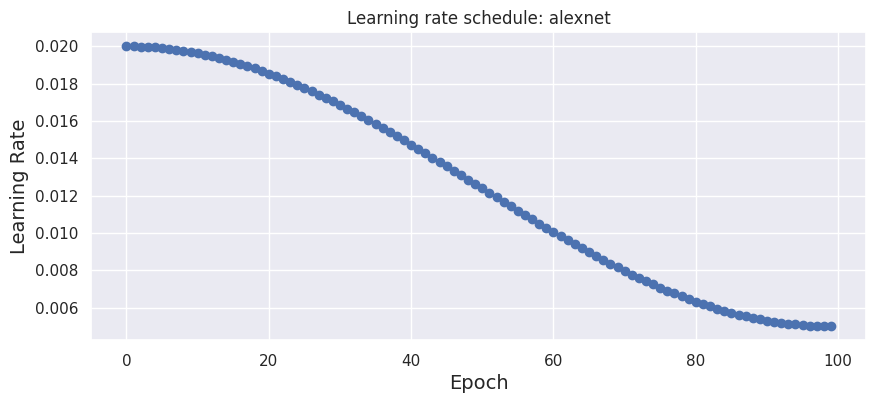


Epoch 1: LearningRateScheduler setting learning rate to 0.02.
Epoch 1/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - head_1_accuracy: 0.4038 - head_1_loss: 1.7169 - head_2_accuracy: 0.3382 - head_2_loss: 1.7626 - head_3_accuracy: 0.4000 - head_3_loss: 1.7303 - head_4_accuracy: 0.4046 - head_4_loss: 1.7614 - head_5_accuracy: 0.4027 - head_5_loss: 1.7275 - head_6_accuracy: 0.3683 - head_6_loss: 1.7309 - head_7_accuracy: 0.3772 - head_7_loss: 1.7094 - loss: 12.1399
Epoch 1: val_head_1_accuracy improved from None to 0.42413, saving model to /content/drive/My Drive/m_p/saved_models/AlexNet_CNN_MultiHead_best.keras

Epoch 1: finished saving model to /content/drive/My Drive/m_p/saved_models/AlexNet_CNN_MultiHead_best.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 33s 171ms/step - head_1_accuracy: 0.4403 - head_1_loss: 1.5832 - head_2_accuracy: 0.4105 - head_2_loss: 1.6064 - head_3_accuracy: 0.4336 - head_3_loss: 1.5807 - head_4_accuracy: 0.4339 - head_4_loss: 1.6107 - head_5_accuracy: 0.4283 - head_5_l

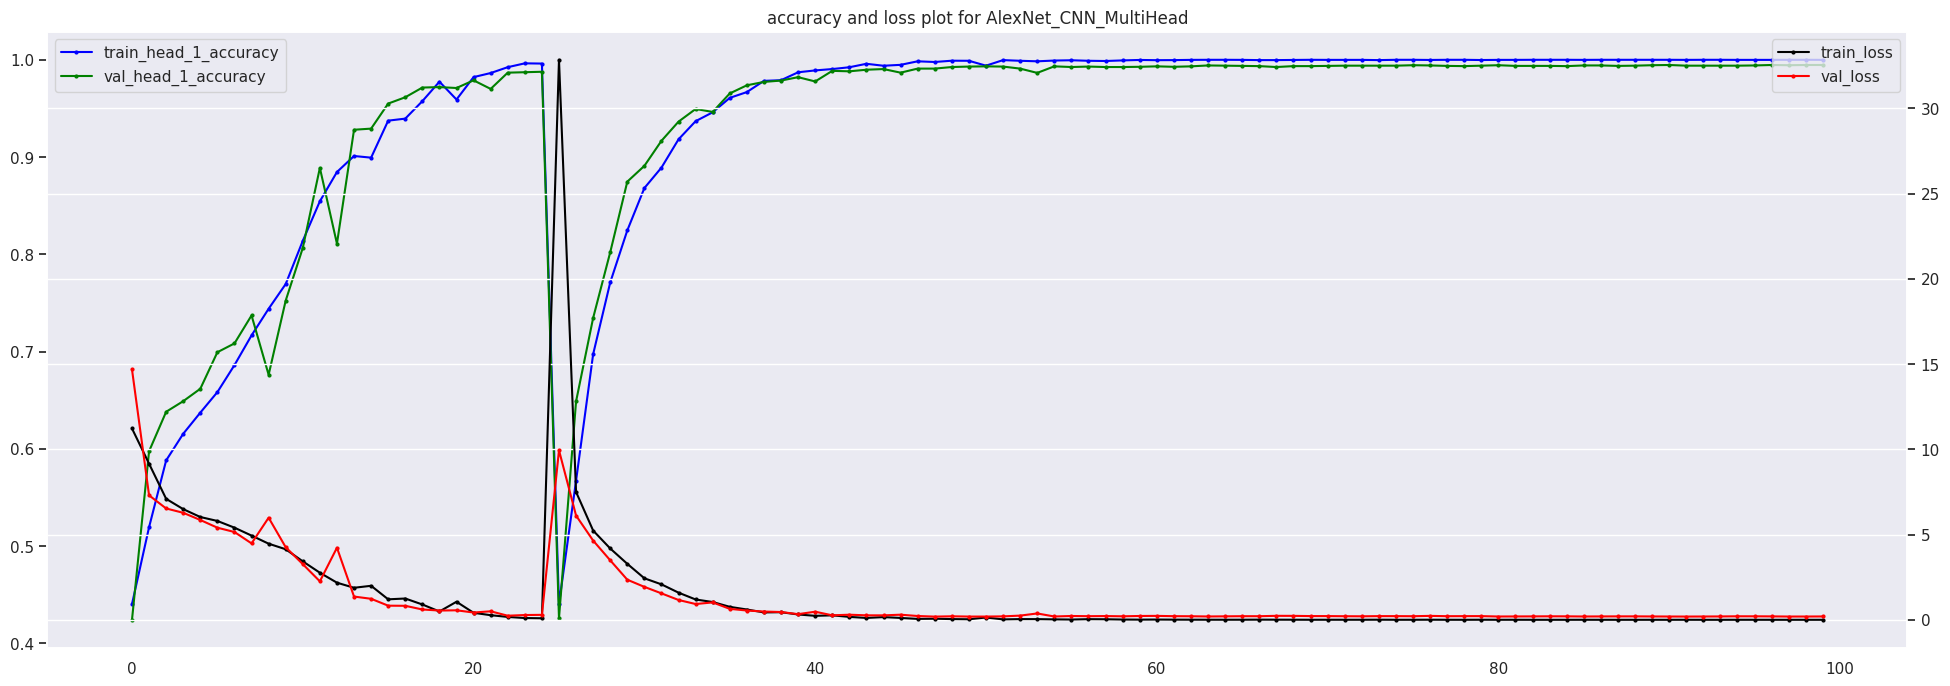


============================== Training GFNet_MultiHead ==============================


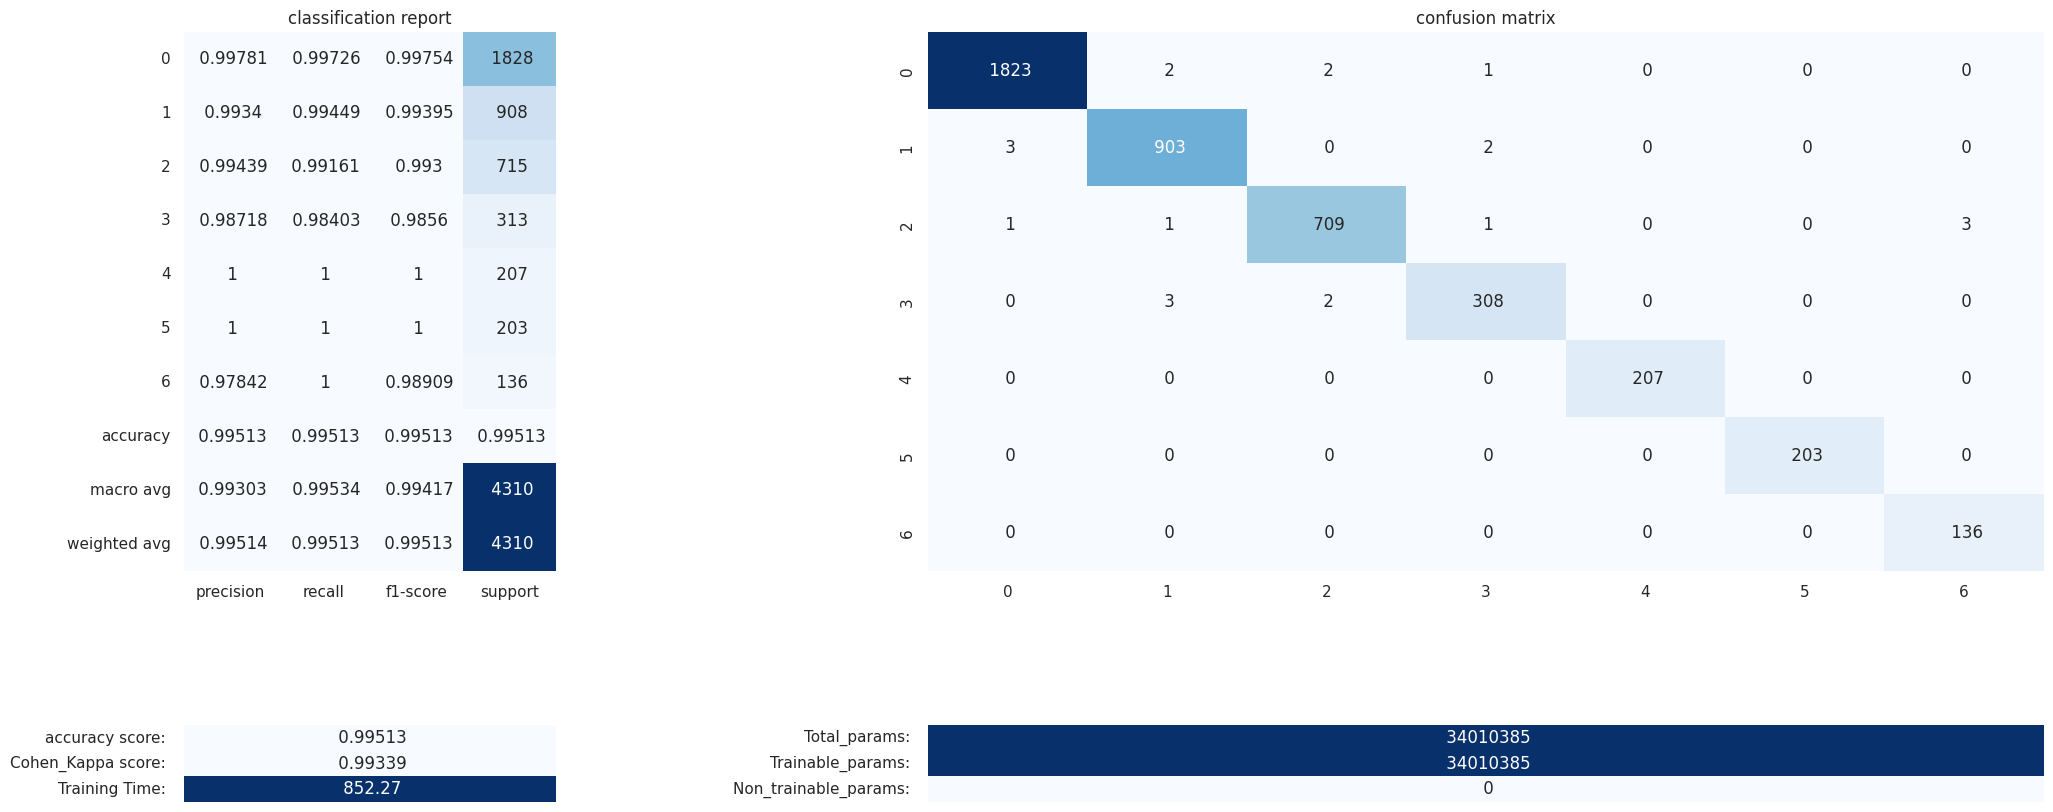

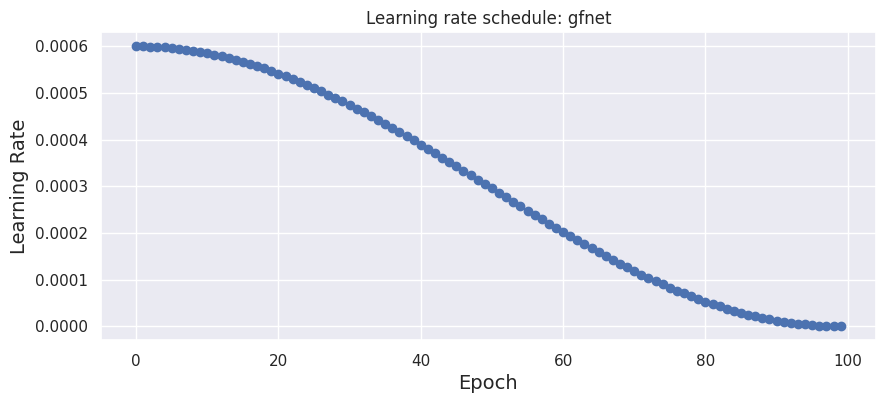


Epoch 1: LearningRateScheduler setting learning rate to 0.0006.
Epoch 1/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - head_1_accuracy: 0.4640 - head_1_loss: 1.5715 - head_2_accuracy: 0.4574 - head_2_loss: 1.6279 - head_3_accuracy: 0.4851 - head_3_loss: 1.4113 - head_4_accuracy: 0.4864 - head_4_loss: 1.4108 - head_5_accuracy: 0.4713 - head_5_loss: 1.4806 - head_6_accuracy: 0.4497 - head_6_loss: 1.5988 - head_7_accuracy: 0.4701 - head_7_loss: 1.4964 - loss: 10.5981
Epoch 1: val_head_1_accuracy improved from None to 0.70696, saving model to /content/drive/My Drive/m_p/saved_models/GFNet_MultiHead_best.keras

Epoch 1: finished saving model to /content/drive/My Drive/m_p/saved_models/GFNet_MultiHead_best.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 107s 554ms/step - head_1_accuracy: 0.5544 - head_1_loss: 1.1778 - head_2_accuracy: 0.5476 - head_2_loss: 1.1973 - head_3_accuracy: 0.5668 - head_3_loss: 1.1285 - head_4_accuracy: 0.5605 - head_4_loss: 1.1330 - head_5_accuracy: 0.5558 - head_5_loss: 1.1

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'gf__patch_encoder', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'gf__block', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'gf__block_1', however the layer does 

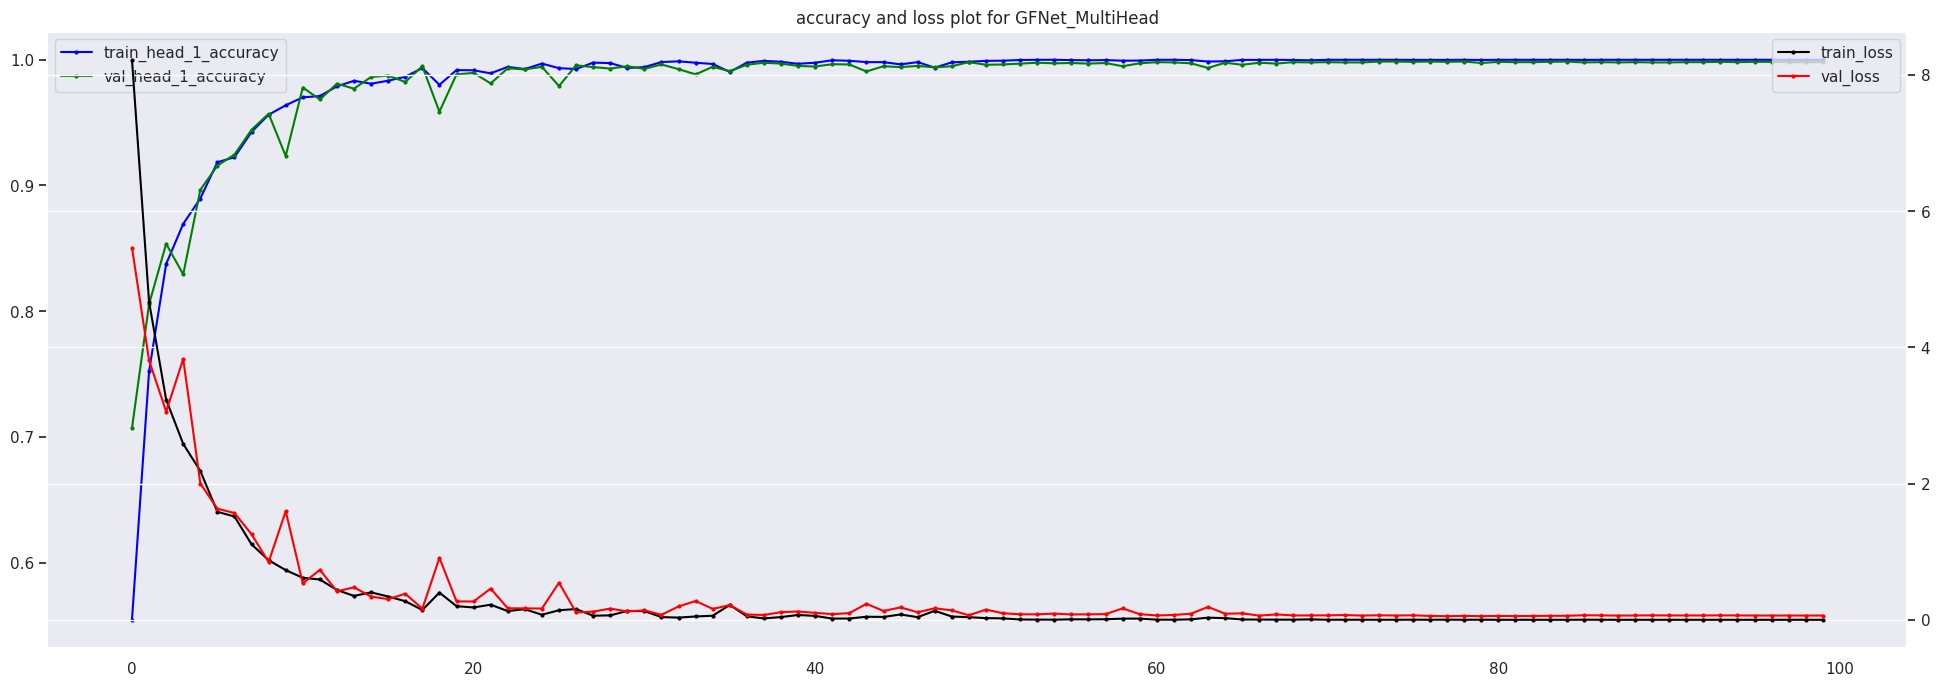


============================== Training ViT_UNet_MultiHead ==============================


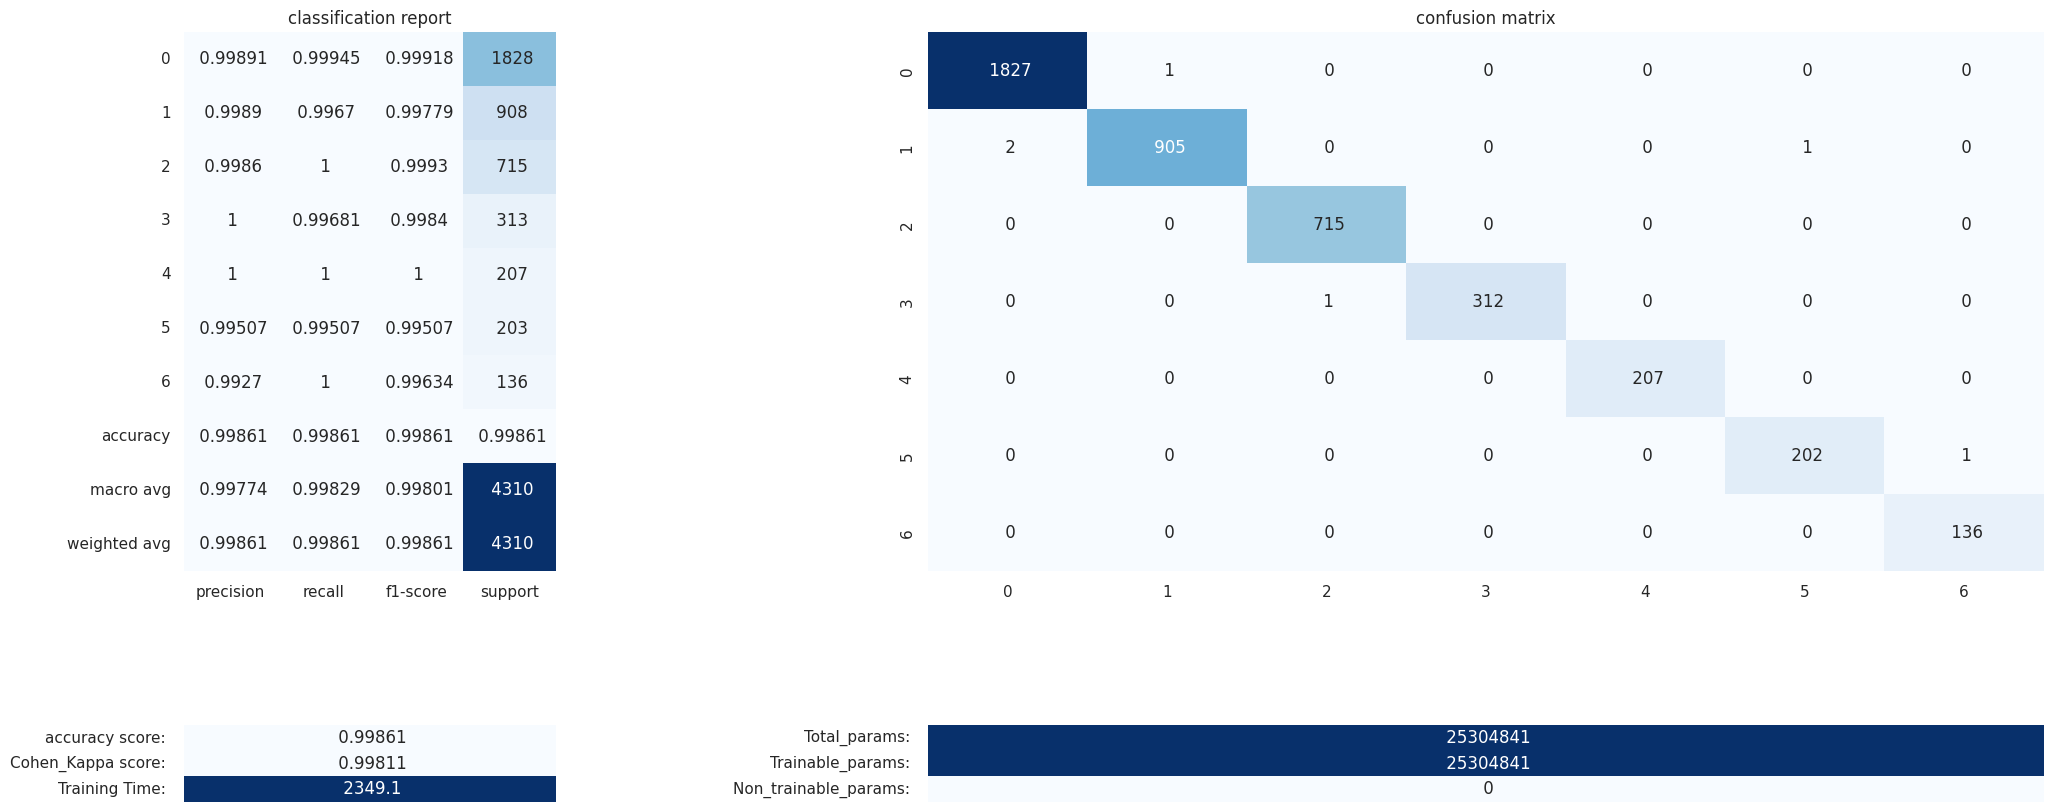

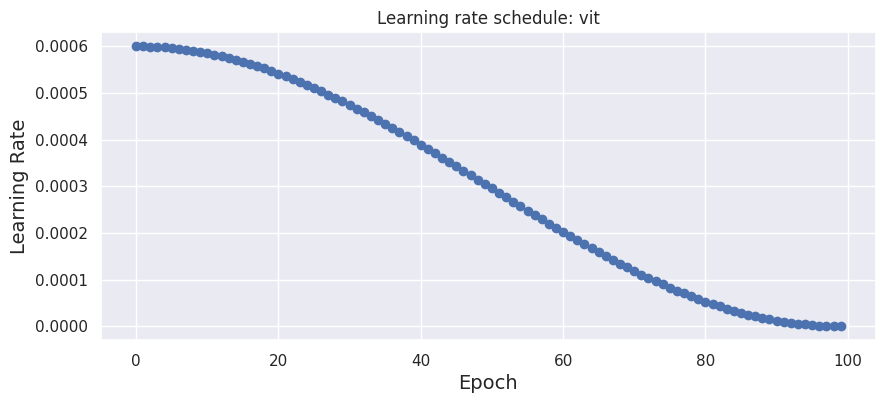


Epoch 1: LearningRateScheduler setting learning rate to 0.0006.
Epoch 1/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 613ms/step - head_1_accuracy: 0.4103 - head_1_loss: 1.4964 - head_2_accuracy: 0.4648 - head_2_loss: 1.4032 - head_3_accuracy: 0.4805 - head_3_loss: 1.3856 - head_4_accuracy: 0.4569 - head_4_loss: 1.3776 - head_5_accuracy: 0.4762 - head_5_loss: 1.3905 - head_6_accuracy: 0.4720 - head_6_loss: 1.4411 - head_7_accuracy: 0.4819 - head_7_loss: 1.3684 - loss: 9.8636
Epoch 1: val_head_1_accuracy improved from None to 0.78515, saving model to /content/drive/My Drive/m_p/saved_models/ViT_UNet_MultiHead_best.keras

Epoch 1: finished saving model to /content/drive/My Drive/m_p/saved_models/ViT_UNet_MultiHead_best.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 162s 757ms/step - head_1_accuracy: 0.5432 - head_1_loss: 1.1880 - head_2_accuracy: 0.5688 - head_2_loss: 1.1521 - head_3_accuracy: 0.5778 - head_3_loss: 1.1304 - head_4_accuracy: 0.5616 - head_4_loss: 1.1332 - head_5_accuracy: 0.5813 - head_5_loss

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'vi_t__patch_encoder', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'vi_t__class__token__norm', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


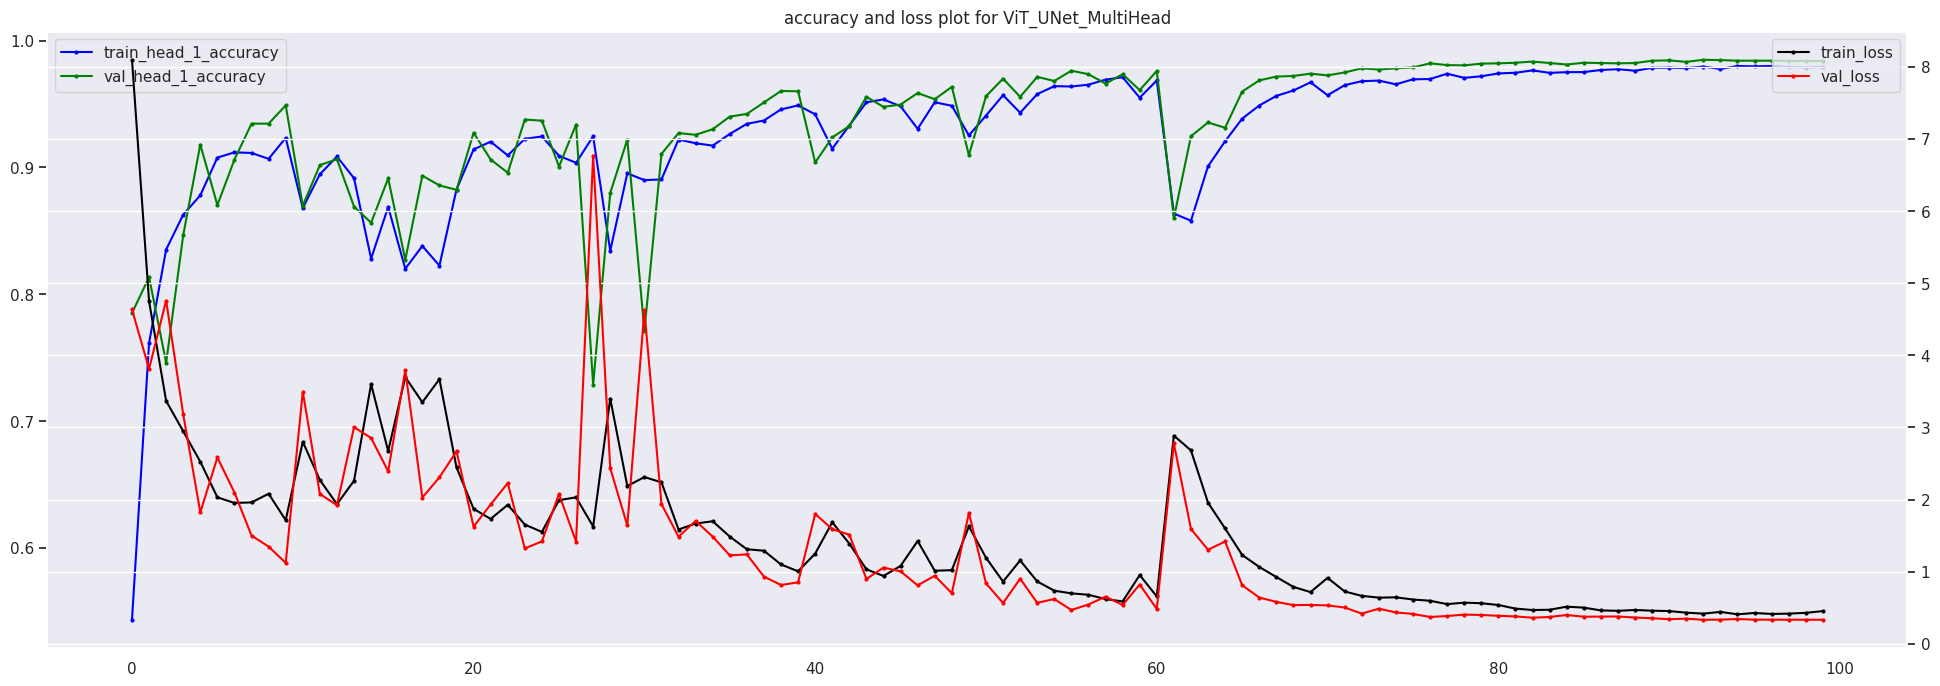

Saved training workbook to /content/drive/My Drive/m_p/saved_models/model_training_multihead_results.xlsx
Saved model registry to /content/drive/My Drive/m_p/saved_models/model_registry_multihead.json


,model_name,best_model_path,final_model_path,test_accuracy,cohen_kappa,training_time_sec,total_params,trainable_params,non_trainable_params
0,AlexNet_CNN_MultiHead,/content/drive/My Drive/m_p/saved_models/AlexN...,/content/drive/My Drive/m_p/saved_models/AlexN...,0.995128,0.993394,852.273026,34010385,34010385,0
1,GFNet_MultiHead,/content/drive/My Drive/m_p/saved_models/GFNet...,/content/drive/My Drive/m_p/saved_models/GFNet...,0.998608,0.998112,2349.147291,25304841,25304841,0
2,ViT_UNet_MultiHead,/content/drive/My Drive/m_p/saved_models/ViT_U...,/content/drive/My Drive/m_p/saved_models/ViT_U...,0.984687,0.979240,1908.407602,16180553,16180553,0


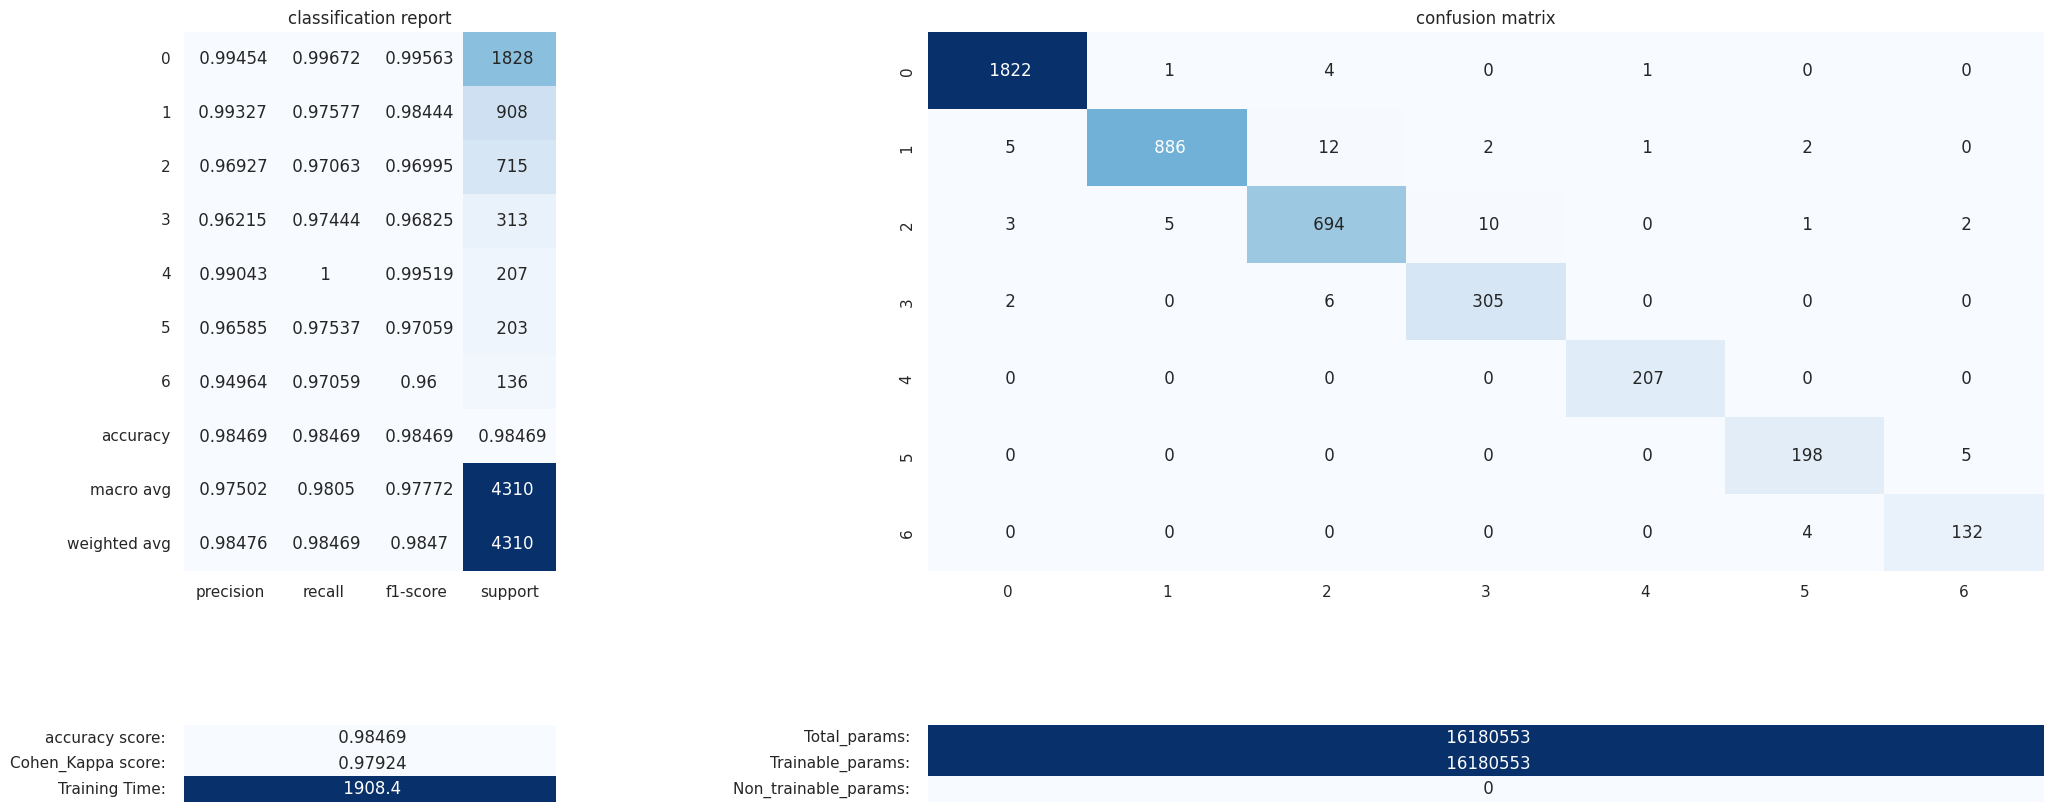

In [8]:
training_wb = ensure_workbook(TRAINING_WORKBOOK)
if 'Summary' in training_wb.sheetnames and len(training_wb.sheetnames) > 1:
    for sheet in training_wb.sheetnames[1:]:
        del training_wb[sheet]
summary_rows = []
registry = {}
for model_name, spec in MODEL_SPECS.items():
    print('\n' + '=' * 30 + f' Training {model_name} ' + '=' * 30)
    summary = run_training(model_name, spec, training_wb)
    summary_rows.append(summary)
    registry[model_name] = {
        'best_model_path': summary['best_model_path'],
        'final_model_path': summary['final_model_path'],
        'custom_objects': sorted(CUSTOM_OBJECTS.keys()),
        'patch_size': P_S,
        'num_classes': num_classes,
        'bands': B,
    }
summary_df = pd.DataFrame(summary_rows)
summary_ws = training_wb['Summary']
summary_ws.delete_rows(1, summary_ws.max_row)
for r_idx, row in enumerate(dataframe_to_rows(summary_df, index=False, header=True), start=1):
    for c_idx, val in enumerate(row, start=1):
        summary_ws.cell(row=r_idx, column=c_idx, value=val)
autosize_columns(summary_ws)
training_wb.save(TRAINING_WORKBOOK)
MODEL_REGISTRY_PATH.write_text(json.dumps(registry, indent=2))
print('Saved training workbook to', TRAINING_WORKBOOK)
print('Saved model registry to', MODEL_REGISTRY_PATH)
summary_df





In [9]:
for model_name, info in json.loads(MODEL_REGISTRY_PATH.read_text()).items():
    print('\nSmoke check:', model_name)
    model = load_model(info['best_model_path'], custom_objects=CUSTOM_OBJECTS, safe_mode=False)
    outputs = model.predict(x_test[:4], verbose=0)
    assert isinstance(outputs, list) and len(outputs) == 7
    print('heads:', len(outputs), '| sample shape:', outputs[0].shape)






Smoke check: AlexNet_CNN_MultiHead
heads: 7 | sample shape: (4, 7)

Smoke check: GFNet_MultiHead


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'gf__patch_encoder', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'gf__block', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'gf__block_1', however the layer does 

heads: 7 | sample shape: (4, 7)

Smoke check: ViT_UNet_MultiHead


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'vi_t__patch_encoder', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'vi_t__class__token__norm', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


heads: 7 | sample shape: (4, 7)
